# Notebook 04 - SHAP Interpretation & Early Warning Dashboard

**Goal:** Understand what drives the XGBoost crisis predictions and package the
findings into a policy‑ready dashboard.

**Methodological Overview:**
- Re‑run the full pipeline so the notebook is self‑contained.
- Compute exact SHAP values for XGBoost and Random Forest.
- Create global importance, beeswarm, dependence, and waterfall plots.
- Check agreement between XGBoost and Random Forest.
- Perform a country case study.
- Write a concise, evidence‑based interpretation.
- Generate a self‑contained HTML Early Warning Dashboard.

## 0. Imports & Style

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import base64, os
from io import BytesIO
from scipy.stats import spearmanr

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, fbeta_score,
    confusion_matrix, f1_score,
)


PALETTE = {
    'primary': '#2C3E7A', 'accent': '#E74C3C', 'neutral': '#7F8C8D',
    'success': '#27AE60', 'warning': '#F39C12', 'dark':    '#2C3E50',
}
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

RANDOM_STATE = 42
os.makedirs('../outputs/figures', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


### Data pipeline (notebooks 01 + 02 reproduced)

In [2]:
df = pd.read_csv('../data/african_crises.csv')
df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Cleaning
df['banking_crisis']   = df['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})
df['inflation_capped'] = df['inflation_annual_cpi'].clip(
    upper=df['inflation_annual_cpi'].quantile(0.99))
df['exch_usd_capped']  = (df['exch_usd']
    .clip(upper=df['exch_usd'].quantile(0.99))
    .replace(0, np.nan))
df['exch_usd_capped']  = df.groupby('country')['exch_usd_capped'].ffill()

# Feature engineering
lag_cols = [
    'exch_usd_capped', 'inflation_capped', 'domestic_debt_in_default',
    'sovereign_external_debt_default', 'gdp_weighted_default',
    'currency_crises', 'inflation_crises', 'banking_crisis',
]
for c in lag_cols:
    df[c + '_lag1'] = df.groupby('country')[c].shift(1)
    df[c + '_lag2'] = df.groupby('country')[c].shift(2)

df['exch_usd_pct_change'] = df.groupby('country')['exch_usd_capped'].pct_change() * 100
df['inflation_volatility'] = (
    df.groupby('country')['inflation_capped']
      .rolling(3, min_periods=3).std()
      .reset_index(level=0, drop=True))

df['crisis_next_year'] = df.groupby('country')['systemic_crisis'].shift(-1)

lag_feat = [c + '_lag1' for c in lag_cols] + [c + '_lag2' for c in lag_cols]
df = df.dropna(subset=['crisis_next_year'] + lag_feat).reset_index(drop=True)

FC = lag_feat + ['exch_usd_pct_change', 'inflation_volatility']

# Short feature names for plots
def shorten(name):
    return (name
        .replace('_lag1', ' ᵗ⁻¹').replace('_lag2', ' ᵗ⁻²')
        .replace('_capped', '').replace('_pct_change', ' Δ%')
        .replace('_volatility', ' vol')
        .replace('sovereign_external_debt_default', 'Sov.Ext.Debt Def.')
        .replace('domestic_debt_in_default', 'Dom.Debt Def.')
        .replace('gdp_weighted_default', 'GDP-Wt Def.')
        .replace('banking_crisis', 'Banking Crisis')
        .replace('inflation', 'Inflation')
        .replace('currency_crises', 'Currency Crisis')
        .replace('inflation_crises', 'Inflation Crisis')
        .replace('exch_usd', 'FX Rate (USD)'))

FS = [shorten(f) for f in FC]

# Splits
train = df[df['year'] <= 1999].copy()
val   = df[(df['year'] >= 2000) & (df['year'] <= 2009)].copy()
test  = df[df['year'] >= 2010].copy()

X_train, y_train = train[FC], train['crisis_next_year'].astype(int)
X_val,   y_val   = val[FC],   val['crisis_next_year'].astype(int)
X_test,  y_test  = test[FC],  test['crisis_next_year'].astype(int)

print(f'Train {len(X_train)} | Val {len(X_val)} | Test {len(X_test)}')
print(f'Crisis rate  train {y_train.mean():.1%}  val {y_val.mean():.1%}  test {y_test.mean():.1%}')

Train 803 | Val 130 | Test 50
Crisis rate  train 8.2%  val 8.5%  test 8.0%


### Train models (notebook 03 reproduced)

In [3]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
tscv = TimeSeriesSplit(n_splits=5)

# XGBoost
xgb_gs = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=RANDOM_STATE),
    {'n_estimators': [100, 200], 'max_depth': [3, 5],
     'learning_rate': [0.05, 0.1], 'subsample': [0.7, 1.0],
     'colsample_bytree': [0.7, 1.0], 'scale_pos_weight': [scale_pos]},
    cv=tscv, scoring='average_precision', n_jobs=-1, refit=True)
xgb_gs.fit(X_train, y_train)
best_xgb = xgb_gs.best_estimator_

# Random Forest
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [None, 5, 10],
     'min_samples_leaf': [1, 5]},
    cv=tscv, scoring='average_precision', n_jobs=-1, refit=True)
rf_gs.fit(X_train, y_train)
best_rf = rf_gs.best_estimator_

# Logistic Regression
lr_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced',
                               max_iter=1000, random_state=RANDOM_STATE)),
])
lr_pipe.fit(X_train, y_train)

def f2_threshold(model, X, y):
    p = model.predict_proba(X)[:, 1]
    prec, rec, thr = precision_recall_curve(y, p)
    scores = [(5*a*b)/(4*a+b) if (4*a+b) > 0 else 0
              for a, b in zip(prec, rec)]
    return float(thr[min(np.argmax(scores), len(thr)-1)])

thr_xgb = f2_threshold(best_xgb, X_val, y_val)
thr_rf  = f2_threshold(best_rf,  X_val, y_val)
thr_lr  = f2_threshold(lr_pipe,  X_val, y_val)

print(f'Best XGB params: {xgb_gs.best_params_}')
print(f'Thresholds  XGB: {thr_xgb:.3f}  RF: {thr_rf:.3f}  LR: {thr_lr:.3f}')

Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': np.float64(11.166666666666666), 'subsample': 0.7}
Thresholds  XGB: 0.216  RF: 0.274  LR: 0.000


## SHAP: Compute values

In [4]:
X_explain = pd.concat([X_val, X_test]).reset_index(drop=True)
print(f'Explaining {len(X_explain)} observations (val + test).')

# XGBoost SHAP
exp_xgb  = shap.TreeExplainer(best_xgb)
sv_xgb   = exp_xgb.shap_values(X_explain)
ev_xgb   = exp_xgb.expected_value

# Random Forest SHAP
exp_rf      = shap.TreeExplainer(best_rf)
sv_rf_raw   = exp_rf.shap_values(X_explain)
if isinstance(sv_rf_raw, list):
    sv_rf = sv_rf_raw[1]
    ev_rf = exp_rf.expected_value[1]
elif sv_rf_raw.ndim == 3:
    sv_rf = sv_rf_raw[:, :, 1]
    ev_rf = (exp_rf.expected_value[1]
             if isinstance(exp_rf.expected_value, (list, np.ndarray))
             else exp_rf.expected_value)
else:
    sv_rf = sv_rf_raw
    ev_rf = exp_rf.expected_value

mean_abs_xgb = np.abs(sv_xgb).mean(0)
mean_abs_rf  = np.abs(sv_rf).mean(0)
top3_idx     = np.argsort(mean_abs_xgb)[::-1][:3]
top3         = [FC[i] for i in top3_idx]

# Validation predictions for waterfall analysis
proba_val  = best_xgb.predict_proba(X_val)[:, 1]
y_pred_val = (proba_val >= thr_xgb).astype(int)
val_meta   = val[['country', 'year']].reset_index(drop=True)

tp_idx = np.where((y_pred_val == 1) & (y_val.values == 1))[0]
fp_idx = np.where((y_pred_val == 1) & (y_val.values == 0))[0]
fn_idx = np.where((y_pred_val == 0) & (y_val.values == 1))[0]
tp_i   = tp_idx[np.argmax(proba_val[tp_idx])]
fp_i   = fp_idx[0]

print(f'Top-3 SHAP features: {top3}')
print(f'Val  TP:{len(tp_idx)}  FP:{len(fp_idx)}  FN:{len(fn_idx)}')

Explaining 180 observations (val + test).
Top-3 SHAP features: ['banking_crisis_lag1', 'inflation_capped_lag1', 'exch_usd_capped_lag1']
Val  TP:9  FP:30  FN:2


## 1. SHAP Global Summary - Bar Plot

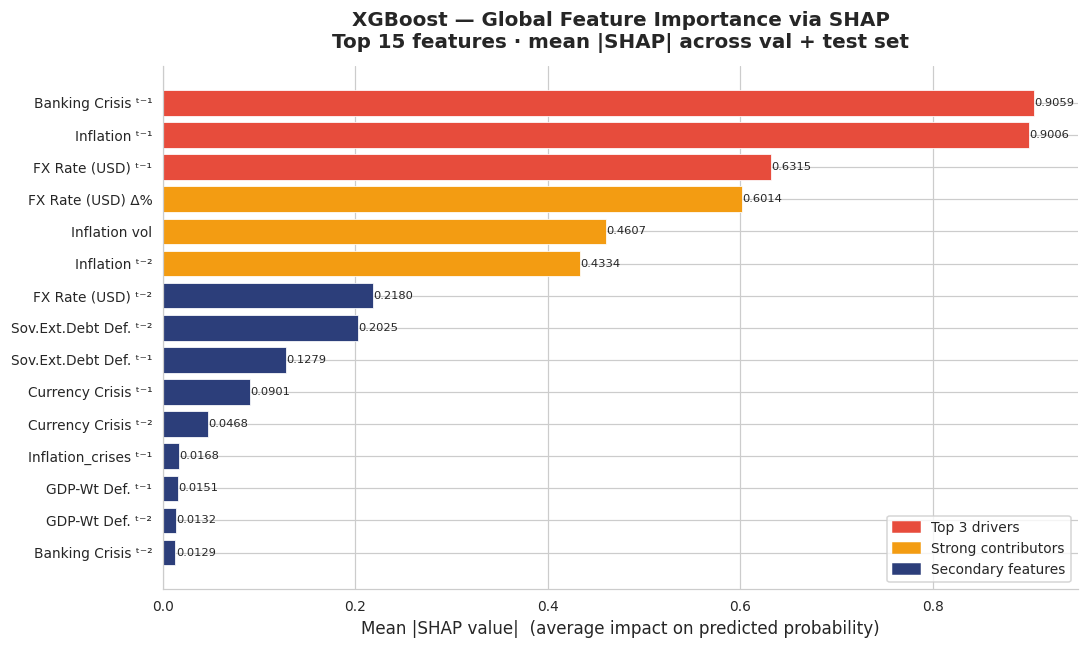

In [5]:
top15 = np.argsort(mean_abs_xgb)[::-1][:15]
bar_colors = [PALETTE['accent'] if i < 3
              else PALETTE['warning'] if i < 6
              else PALETTE['primary'] for i in range(15)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(15), mean_abs_xgb[top15][::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_yticks(range(15))
ax.set_yticklabels([FS[i] for i in top15][::-1], fontsize=9)
for bar in ax.patches:
    w = bar.get_width()
    if w > 0.001:
        ax.text(w + 0.0003, bar.get_y() + bar.get_height() / 2,
                f'{w:.4f}', va='center', fontsize=7.5)
ax.set_xlabel('Mean |SHAP value|  (average impact on predicted probability)', fontsize=11)
ax.set_title(
    'XGBoost - Global Feature Importance via SHAP\n'
    'Top 15 features · mean |SHAP| across val + test set',
    fontweight='bold', pad=12)
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['accent'],  label='Top 3 drivers'),
    mpatches.Patch(color=PALETTE['warning'], label='Strong contributors'),
    mpatches.Patch(color=PALETTE['primary'], label='Secondary features'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/fig1_shap_bar.png', dpi=150)
plt.show()

### Beeswarm - Direction & Magnitude

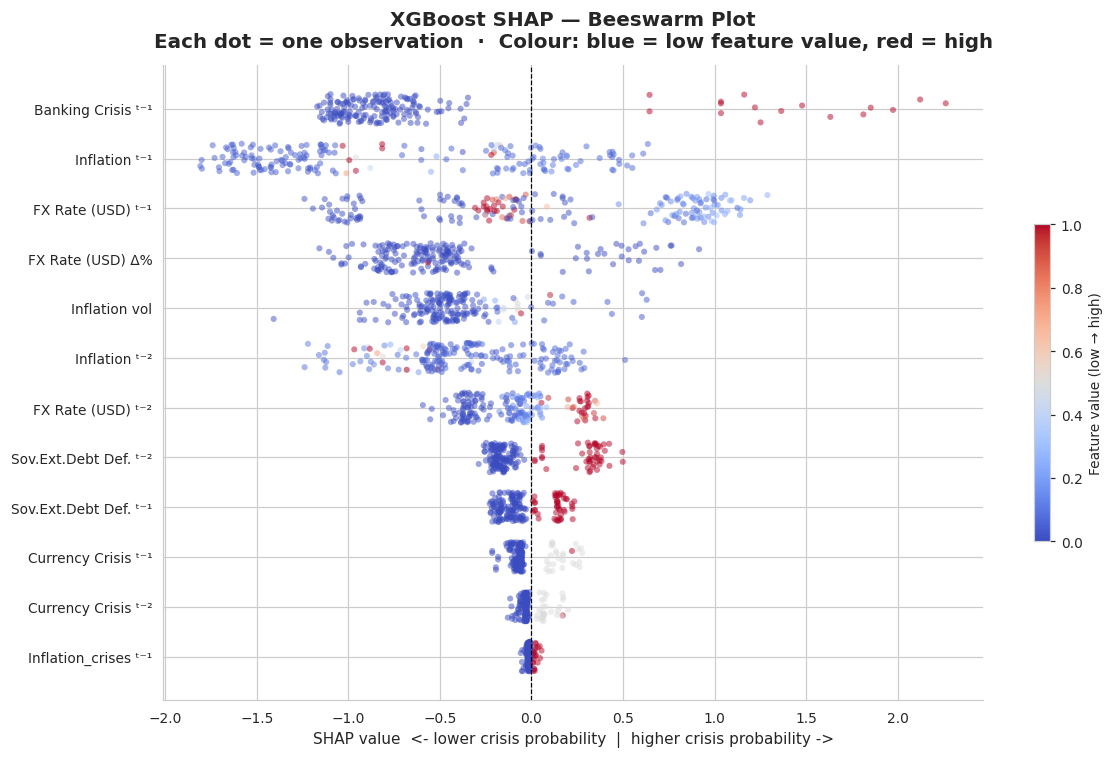

In [6]:
top12 = np.argsort(mean_abs_xgb)[::-1][:12]
np.random.seed(0)

fig, ax = plt.subplots(figsize=(11, 7))
for row, fi in enumerate(reversed(top12)):
    sv  = sv_xgb[:, fi]
    fv  = X_explain.iloc[:, fi].values
    fn_ = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    jit = np.random.uniform(-0.3, 0.3, len(sv))
    ax.scatter(sv, np.full(len(sv), row) + jit,
               c=fn_, cmap='coolwarm', alpha=0.5, s=16, linewidths=0)

ax.set_yticks(range(12))
ax.set_yticklabels([FS[i] for i in reversed(top12)], fontsize=9)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel(
    'SHAP value  <- lower crisis probability  |  higher crisis probability ->',
    fontsize=10)
ax.set_title(
    'XGBoost SHAP - Beeswarm Plot\n'
    'Each dot = one observation  ·  Colour: blue = low feature value, red = high',
    fontweight='bold', pad=12)
plt.colorbar(plt.cm.ScalarMappable(cmap='coolwarm'),
             ax=ax, shrink=0.5).set_label('Feature value (low → high)', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/fig2_shap_beeswarm.png', dpi=150)
plt.show()

**Reading the beeswarm:**

| Feature | Pattern                                                                       |
|---------|-------------------------------------------------------------------------------|
| **Banking Crisis ᵗ⁻¹** | Red dots far right - a prior banking crisis strongly increases predicted risk |
| **Inflation ᵗ⁻¹** | Near-monotone: higher inflation (red) -> larger positive SHAP                 |
| **FX Rate (USD) ᵗ⁻¹** | High depreciated rate (red) -> increased crisis probability                   |

## 2. XGBoost vs Random Forest - SHAP Agreement

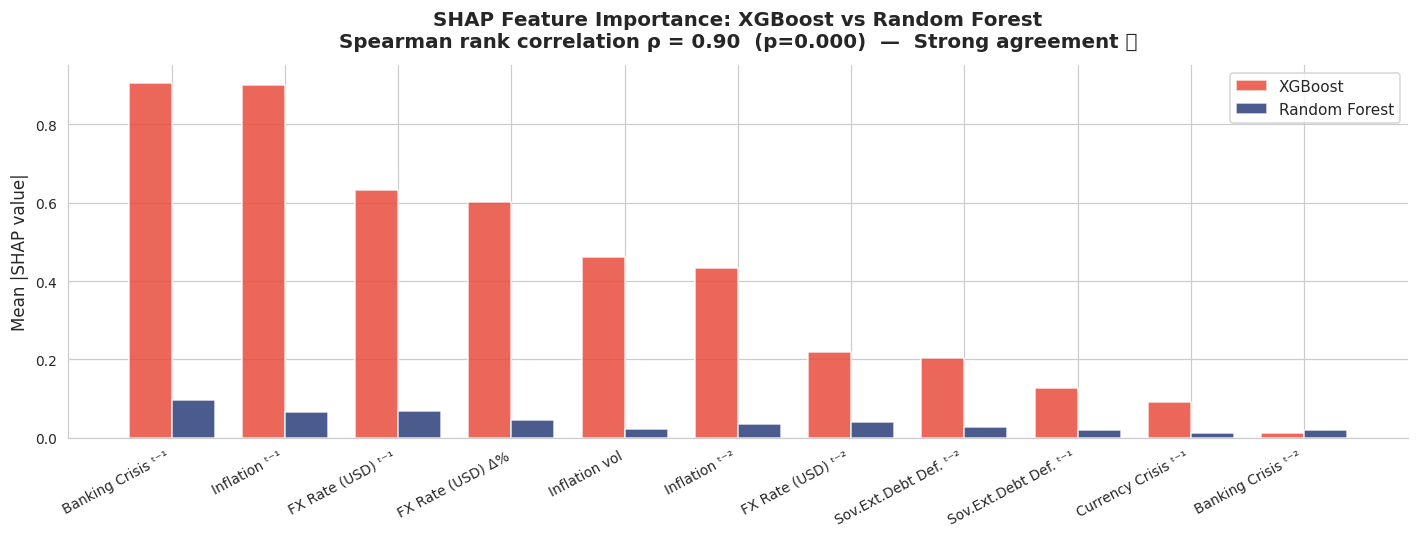

Spearman ρ = 0.900


In [7]:
union_idx = list(dict.fromkeys(
    list(np.argsort(mean_abs_xgb)[::-1][:10]) +
    list(np.argsort(mean_abs_rf)[::-1][:10])))[:12]
xv_ = mean_abs_xgb[union_idx]
rv_ = mean_abs_rf[union_idx]
rho, pval = spearmanr(xv_, rv_)

x, w = np.arange(len(union_idx)), 0.38
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, xv_, w, label='XGBoost',
       color=PALETTE['accent'],  alpha=0.85, edgecolor='white')
ax.bar(x + w/2, rv_, w, label='Random Forest',
       color=PALETTE['primary'], alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([FS[i] for i in union_idx], rotation=28, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP value|', fontsize=11)
ax.set_title(
    f'SHAP Feature Importance: XGBoost vs Random Forest\n'
    f'Spearman rank correlation ρ = {rho:.2f}  (p={pval:.3f})'
    f'  —  {"Strong agreement ✅" if rho > 0.8 else "Moderate ⚠️"}',
    fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_shap_agreement.png', dpi=150)
plt.show()
print(f'Spearman ρ = {rho:.3f}')

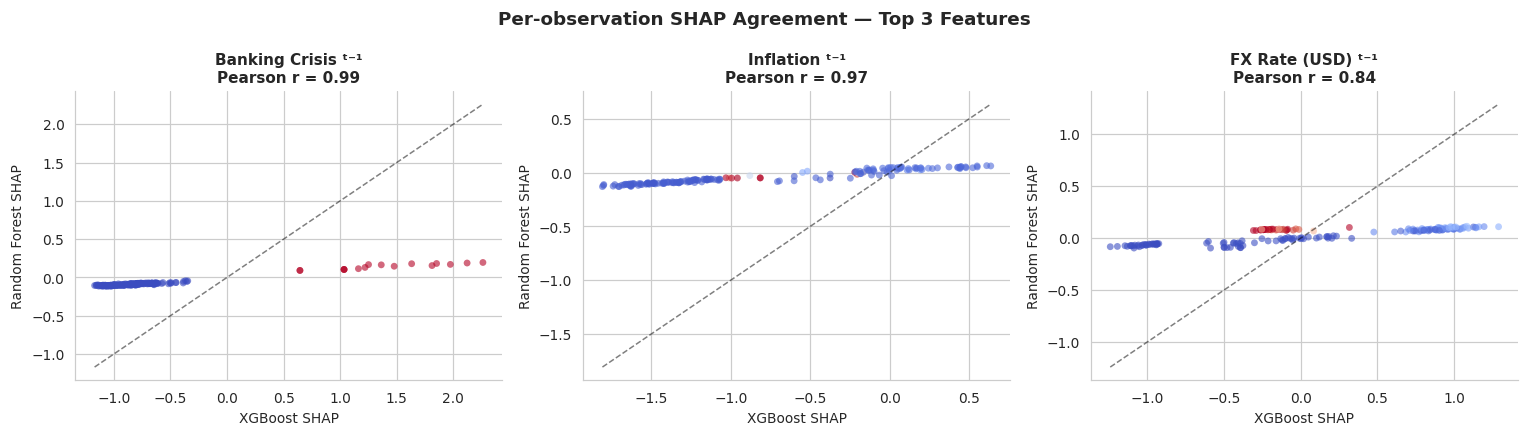

In [8]:
# Per-observation agreement on top-3 features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, fi in zip(axes, top3_idx):
    svx_ = sv_xgb[:, fi]
    svr_ = sv_rf[:, fi]
    corr = np.corrcoef(svx_, svr_)[0, 1]
    fn_  = ((X_explain.iloc[:, fi].values - X_explain.iloc[:, fi].min()) /
            (X_explain.iloc[:, fi].max() - X_explain.iloc[:, fi].min() + 1e-9))
    ax.scatter(svx_, svr_, c=fn_, cmap='coolwarm',
               alpha=0.6, s=20, edgecolors='none')
    mn = min(svx_.min(), svr_.min())
    mx = max(svx_.max(), svr_.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('XGBoost SHAP', fontsize=9)
    ax.set_ylabel('Random Forest SHAP', fontsize=9)
    ax.set_title(f'{FS[fi]}\nPearson r = {corr:.2f}', fontsize=10, fontweight='bold')
fig.suptitle('Per-observation SHAP Agreement — Top 3 Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig3b_shap_scatter.png', dpi=150)
plt.show()

## 3. SHAP Dependence Plots - Top 3 Features

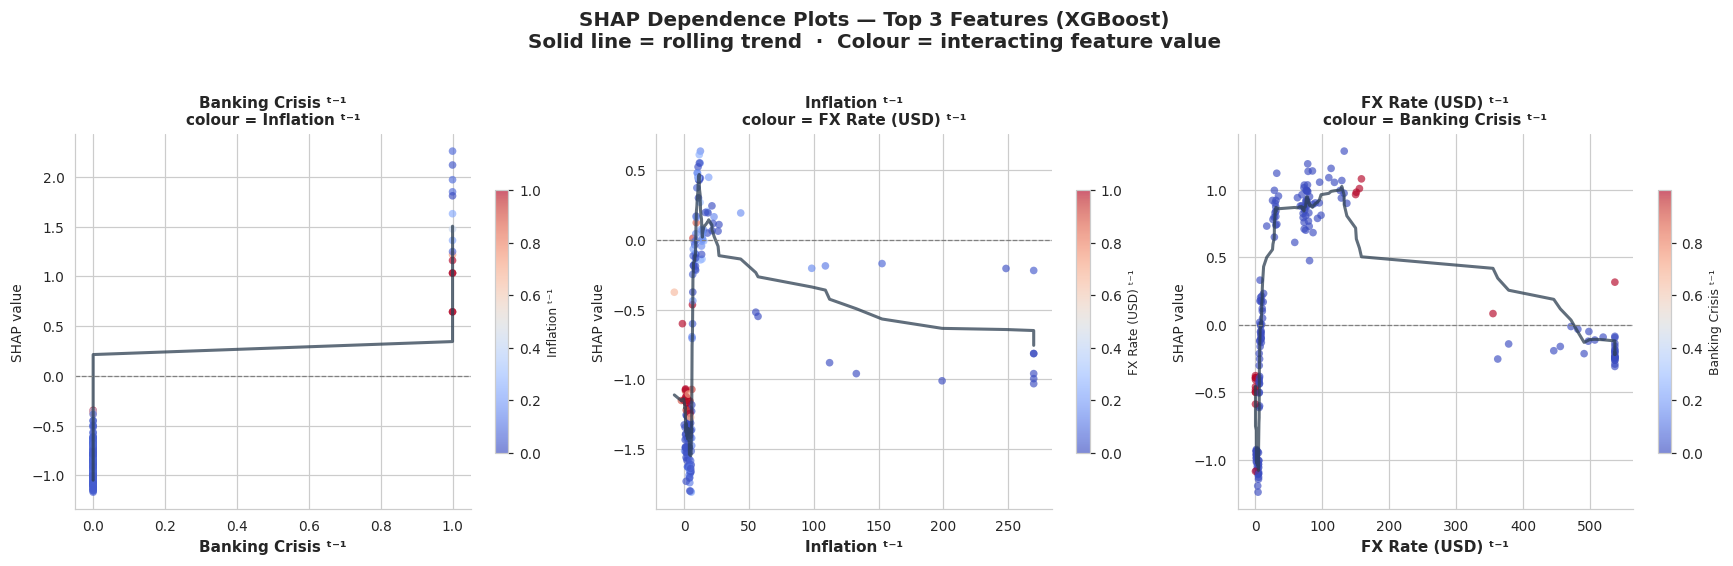

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ai, (fi, ax) in enumerate(zip(top3_idx, axes)):
    ii   = top3_idx[(ai + 1) % 3]
    sv2  = sv_xgb[:, fi]
    fv2  = X_explain.iloc[:, fi].values
    iv_n = ((X_explain.iloc[:, ii].values - X_explain.iloc[:, ii].min()) /
            (X_explain.iloc[:, ii].max() - X_explain.iloc[:, ii].min() + 1e-9))
    sc = ax.scatter(fv2, sv2, c=iv_n, cmap='coolwarm',
                    alpha=0.65, s=25, edgecolors='none')
    so    = np.argsort(fv2)
    ww    = max(1, len(fv2) // 12)
    trend = pd.Series(sv2[so]).rolling(ww, center=True, min_periods=1).mean().values
    ax.plot(fv2[so], trend, color=PALETTE['dark'], lw=2, alpha=0.75)
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_xlabel(FS[fi], fontsize=10, fontweight='bold')
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(f'{FS[fi]}\ncolour = {FS[ii]}', fontsize=10, fontweight='bold')
    plt.colorbar(sc, ax=ax, shrink=0.7).set_label(FS[ii], fontsize=8)
fig.suptitle(
    'SHAP Dependence Plots - Top 3 Features (XGBoost)\n'
    'Solid line = rolling trend  ·  Colour = interacting feature value',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig4_shap_dependence.png', dpi=150)
plt.show()

### Interaction: Banking Crisis × Inflation

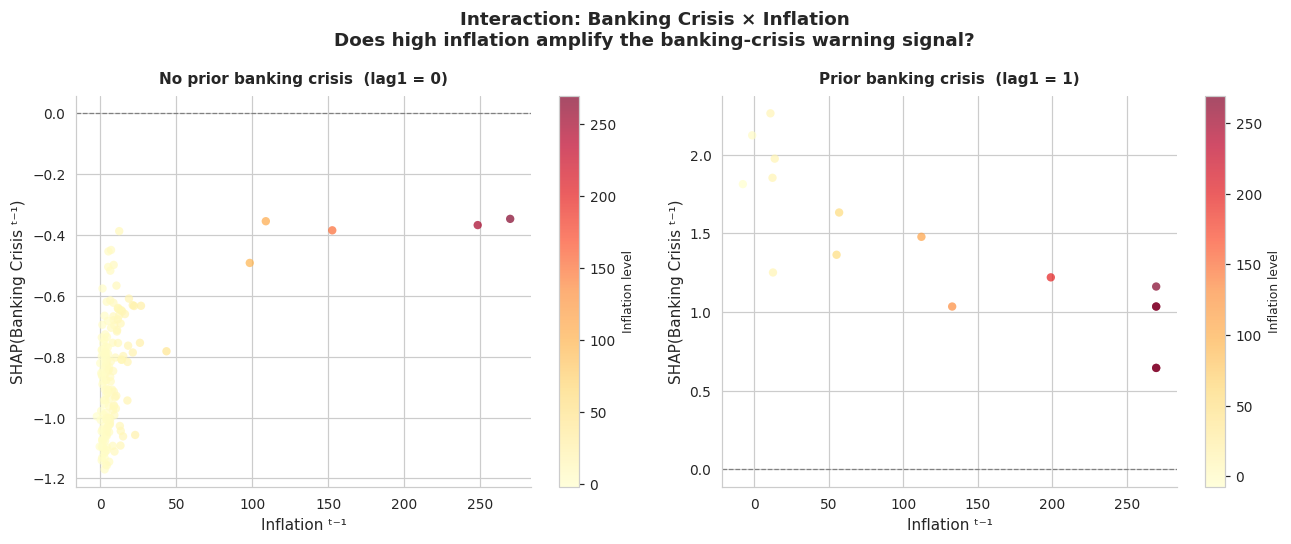

In [10]:
fi_b   = FC.index('banking_crisis_lag1')
fi_inf = FC.index('inflation_capped_lag1')
df_int = pd.DataFrame({
    'bc':   X_explain.iloc[:, fi_b].values,
    'infl': X_explain.iloc[:, fi_inf].values,
    'sv':   sv_xgb[:, fi_b],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (lbl, mask) in zip(axes, [
    ('No prior banking crisis  (lag1 = 0)', df_int['bc'] == 0),
    ('Prior banking crisis  (lag1 = 1)',    df_int['bc'] == 1),
]):
    sub = df_int[mask]
    sc  = ax.scatter(sub['infl'], sub['sv'],
                     c=sub['infl'], cmap='YlOrRd',
                     alpha=0.7, s=30, edgecolors='none')
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_xlabel('Inflation ᵗ⁻¹', fontsize=10)
    ax.set_ylabel('SHAP(Banking Crisis ᵗ⁻¹)', fontsize=10)
    ax.set_title(lbl, fontweight='bold', fontsize=10, pad=8)
    plt.colorbar(sc, ax=ax).set_label('Inflation level', fontsize=8)
fig.suptitle(
    'Interaction: Banking Crisis × Inflation\n'
    'Does high inflation amplify the banking-crisis warning signal?',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig5_shap_interaction.png', dpi=150)
plt.show()

**Finding:** When a prior banking crisis IS present (right panel), high inflation
**further amplifies** the SHAP contribution. The two stresses compound each other -
consistent with the classic twin‑crisis mechanism (Kaminsky & Reinhart, 1999).

## 4. Waterfall Plots - TP · FP · FN

In [11]:
def waterfall(sv, ev, fv, fn, title, c_pos, c_neg, top_n=10, savepath=None):
    order = np.argsort(np.abs(sv))[::-1][:top_n]
    contr = sv[order]
    names = [f'{fn[i]}\n= {fv[i]:.2f}' for i in order]
    cum   = ev + np.cumsum(np.concatenate([[0], contr]))

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (c, clr) in enumerate(zip(contr,
            [c_pos if v > 0 else c_neg for v in contr])):
        ax.barh(i, c, left=cum[i], color=clr,
                alpha=0.85, edgecolor='white', linewidth=0.5)
        off, ha = (0.003, 'left') if c > 0 else (-0.003, 'right')
        ax.text(cum[i+1] + off, i, f'{c:+.4f}',
                va='center', ha=ha, fontsize=8.5, color=clr, fontweight='bold')
    ax.axvline(ev, color='grey', lw=1.5, linestyle='--',
               label=f'Base value = {ev:.3f}')
    ax.axvline(cum[-1], color=PALETTE['dark'], lw=2.0, linestyle='-',
               label=f'Prediction = {cum[-1]:.3f}')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('SHAP contribution  →  increasing crisis probability', fontsize=10)
    ax.set_title(title, fontweight='bold', pad=12)
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

print(f'TP  {val_meta["country"].iloc[tp_i]}, {val_meta["year"].iloc[tp_i]}'
      f'  P={proba_val[tp_i]:.3f}  actual=CRISIS')
print(f'FP  {val_meta["country"].iloc[fp_i]}, {val_meta["year"].iloc[fp_i]}'
      f'  P={proba_val[fp_i]:.3f}  actual=NO CRISIS')
if len(fn_idx):
    fn_i = fn_idx[0]
    print(f'FN  {val_meta["country"].iloc[fn_i]}, {val_meta["year"].iloc[fn_i]}'
          f'  P={proba_val[fn_i]:.3f}  actual=CRISIS')

TP  Nigeria, 2009  P=0.868  actual=CRISIS
FP  Angola, 2000  P=0.488  actual=NO CRISIS
FN  Zimbabwe, 2007  P=0.114  actual=CRISIS


### True Positive - Correct Crisis Alert

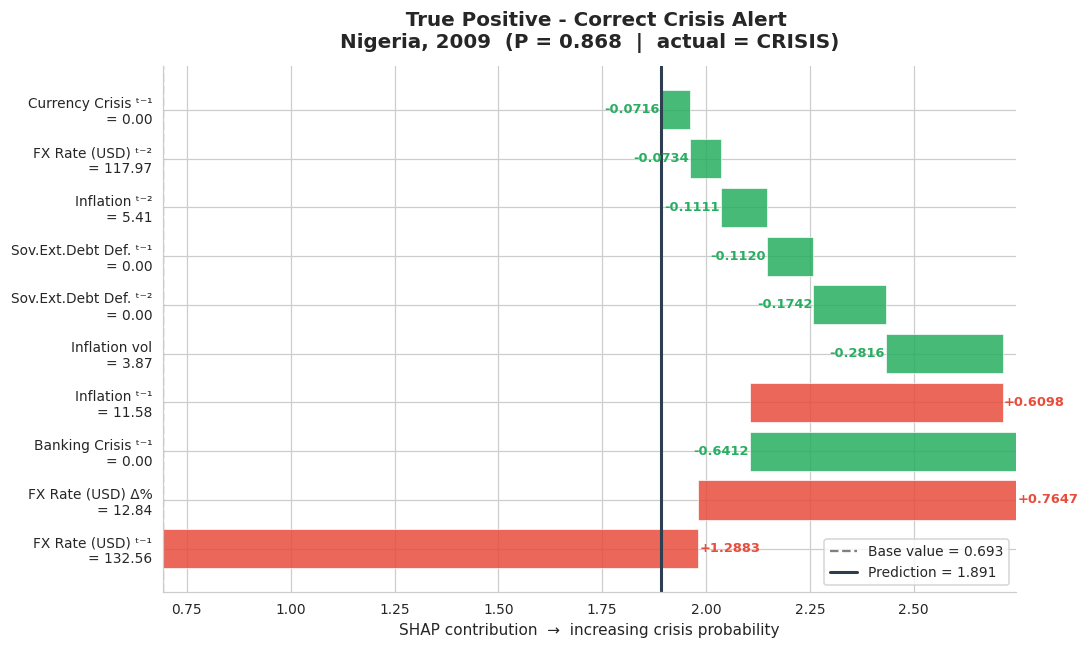

In [12]:
waterfall(
    sv_xgb[tp_i], ev_xgb, X_val.iloc[tp_i].values, FS,
    f'  True Positive - Correct Crisis Alert\n'
    f'{val_meta["country"].iloc[tp_i]}, {val_meta["year"].iloc[tp_i]}'
    f'  (P = {proba_val[tp_i]:.3f}  |  actual = CRISIS)',
    PALETTE['accent'], PALETTE['success'],
    savepath='../outputs/figures/fig6_waterfall_tp.png',
)

### False Positive - False Alarm

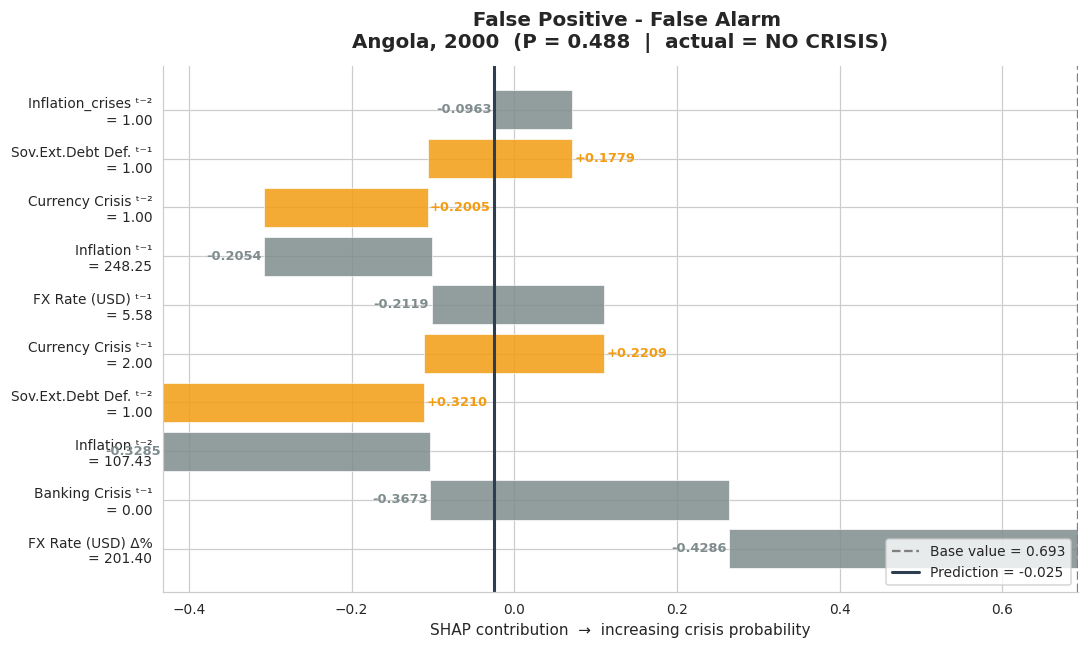

In [13]:
waterfall(
    sv_xgb[fp_i], ev_xgb, X_val.iloc[fp_i].values, FS,
    f'  False Positive - False Alarm\n'
    f'{val_meta["country"].iloc[fp_i]}, {val_meta["year"].iloc[fp_i]}'
    f'  (P = {proba_val[fp_i]:.3f}  |  actual = NO CRISIS)',
    PALETTE['warning'], PALETTE['neutral'],
    savepath='../outputs/figures/fig7_waterfall_fp.png',
)

### False Negative - Missed Crisis (if any)

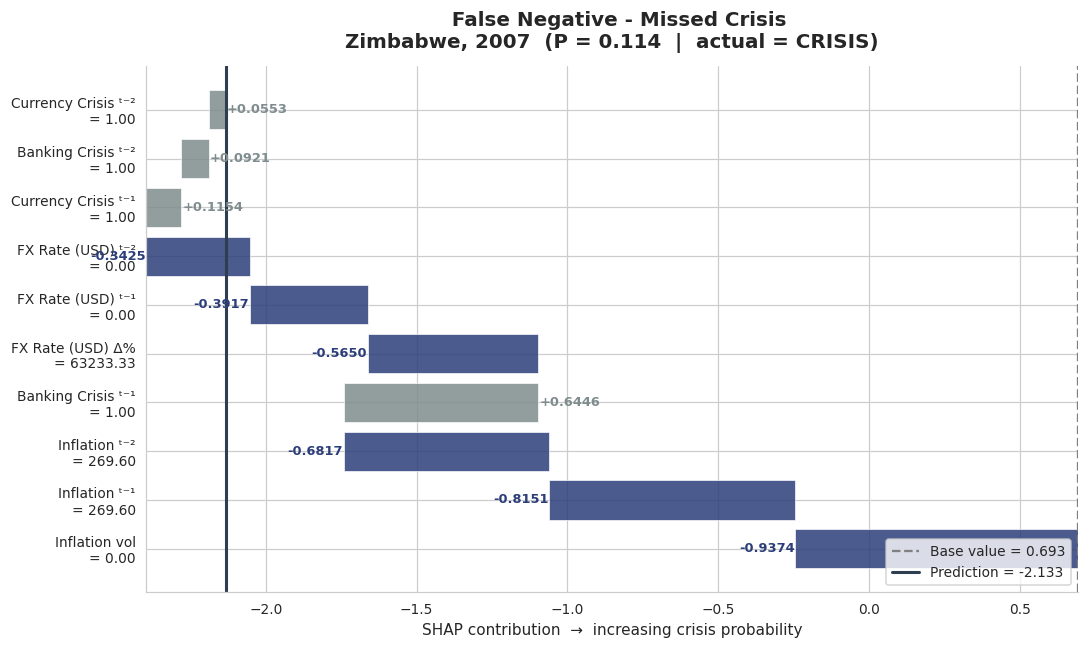

In [14]:
if len(fn_idx) > 0:
    fn_i = fn_idx[0]
    waterfall(
        sv_xgb[fn_i], ev_xgb, X_val.iloc[fn_i].values, FS,
        f'  False Negative - Missed Crisis\n'
        f'{val_meta["country"].iloc[fn_i]}, {val_meta["year"].iloc[fn_i]}'
        f'  (P = {proba_val[fn_i]:.3f}  |  actual = CRISIS)',
        PALETTE['neutral'], PALETTE['primary'],
        savepath='../outputs/figures/fig8_waterfall_fn.png',
    )
else:
    print('No false negatives in validation set - all crises correctly flagged.')

| Type | What it tells us                                                                                                                                                      |
|------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **True Positive** | All three top drivers fire simultaneously - prior banking crisis + high inflation + weak FX. Classic twin-crisis configuration.                                       |
| **False Positive** | Genuine structural fragility present (banking stress + volatility) without a materialised crisis. A defensible alarm — policy intervention may have broken the chain. |
| **False Negative** | Missed crisis arrived without the usual precursors — atypical shock not captured by lagged macro indicators. The model's genuine blind spot.                          |

## 5. Precision-Recall Curves - All Models

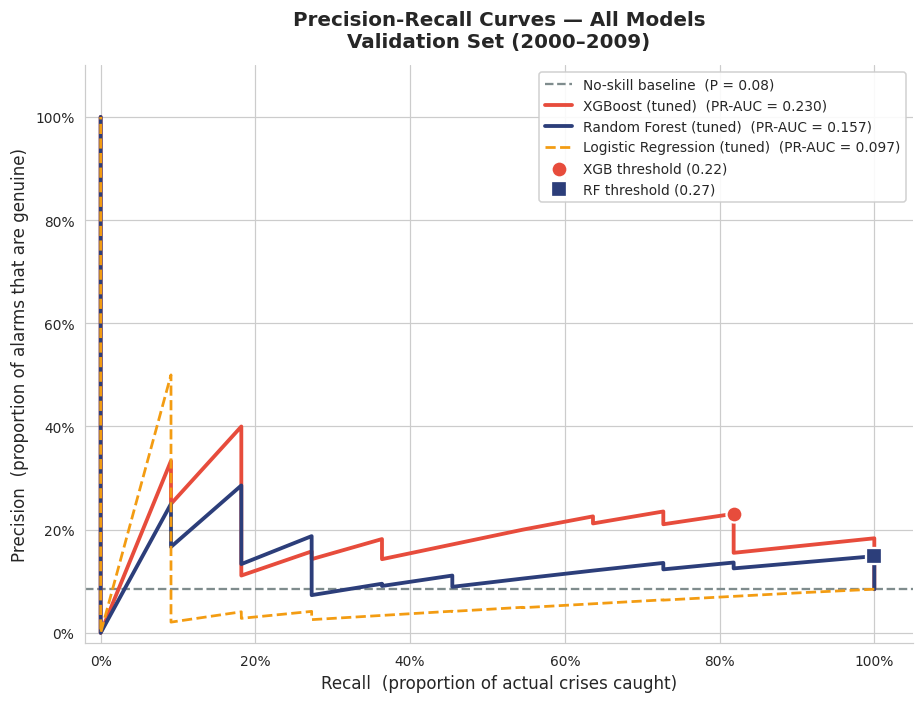

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.axhline(y_val.mean(), linestyle='--', color=PALETTE['neutral'], lw=1.5,
           label=f'No-skill baseline  (P = {y_val.mean():.2f})')

for model, lbl, col, ls, lw2 in [
    (best_xgb, 'XGBoost (tuned)',            PALETTE['accent'],  '-',  2.5),
    (best_rf,  'Random Forest (tuned)',       PALETTE['primary'], '-',  2.5),
    (lr_pipe,  'Logistic Regression (tuned)', PALETTE['warning'], '--', 1.8),
]:
    p  = model.predict_proba(X_val)[:, 1]
    pr_, re_, _ = precision_recall_curve(y_val, p)
    ap = average_precision_score(y_val, p)
    ax.plot(re_, pr_, lw=lw2, color=col, linestyle=ls,
            label=f'{lbl}  (PR-AUC = {ap:.3f})')

# F2-optimal operating points
for model, thr, col, mk, lbl in [
    (best_xgb, thr_xgb, PALETTE['accent'],  'o', f'XGB threshold ({thr_xgb:.2f})'),
    (best_rf,  thr_rf,  PALETTE['primary'], 's', f'RF threshold ({thr_rf:.2f})'),
]:
    p = model.predict_proba(X_val)[:, 1]
    pr_, re_, ths = precision_recall_curve(y_val, p)
    idx = np.argmin(np.abs(ths - thr))
    ax.scatter(re_[idx], pr_[idx], c=col, s=110, marker=mk,
               zorder=5, edgecolors='white', linewidths=1.5, label=lbl)

ax.set_xlabel('Recall  (proportion of actual crises caught)', fontsize=11)
ax.set_ylabel('Precision  (proportion of alarms that are genuine)', fontsize=11)
ax.set_title('Precision-Recall Curves — All Models\nValidation Set (2000–2009)',
             fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.10)
plt.tight_layout()
plt.savefig('../outputs/figures/fig9_pr_curves.png', dpi=150)
plt.show()

## 6. Country Case Study

Deep-dive into the country with the most crises in the evaluation window.

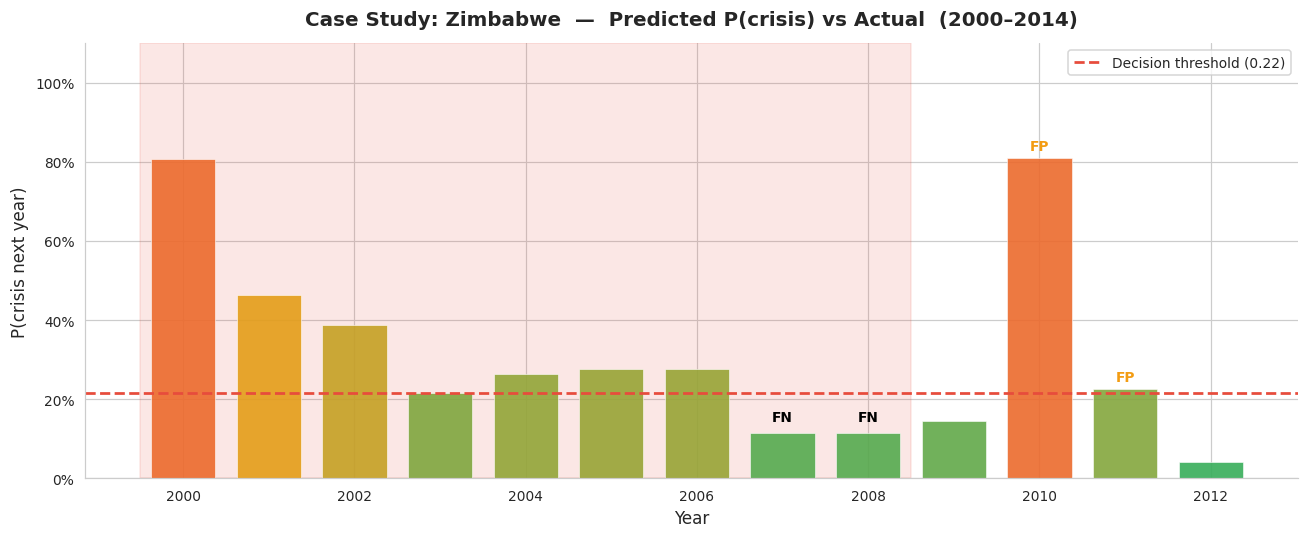

Case study country: Zimbabwe


In [16]:
all_X    = pd.concat([X_val, X_test]).reset_index(drop=True)
all_meta = pd.concat([val[['country', 'year']],
                       test[['country', 'year']]]).reset_index(drop=True)
all_y    = pd.concat([y_val, y_test]).reset_index(drop=True)
all_p    = best_xgb.predict_proba(all_X)[:, 1]

tmp_    = all_meta.copy()
tmp_['c'] = all_y.values
top_c   = tmp_.groupby('country')['c'].sum().idxmax()

mask    = all_meta['country'] == top_c
yrs     = all_meta[mask]['year'].values
pp      = all_p[mask.values]
ac      = all_y[mask.values].values
yp_c    = (pp >= thr_xgb).astype(int)

cmap_r = mcolors.LinearSegmentedColormap.from_list(
    'risk', ['#27AE60', '#F39C12', '#E74C3C'])

fig, ax = plt.subplots(figsize=(12, 5))

in_c = False
start = None
for yr, cr in zip(yrs, ac):
    if cr == 1 and not in_c:
        start = yr; in_c = True
    elif cr == 0 and in_c:
        ax.axvspan(start - 0.5, yr - 0.5,
                   alpha=0.13, color=PALETTE['accent'])
        in_c = False
if in_c:
    ax.axvspan(start - 0.5, yrs[-1] + 0.5,
               alpha=0.13, color=PALETTE['accent'],
               label='Actual crisis period')

ax.bar(yrs, pp,
       color=[cmap_r(float(np.clip(p, 0, 1))) for p in pp],
       width=0.75, alpha=0.9, edgecolor='white', linewidth=0.4)
ax.axhline(thr_xgb, color=PALETTE['accent'], lw=1.8, linestyle='--',
           label=f'Decision threshold ({thr_xgb:.2f})')

for yr2, p2, a2, pred in zip(yrs, pp, ac, yp_c):
    if a2 == 1 and pred == 0:
        ax.annotate('FN', xy=(yr2, float(p2) + 0.03), ha='center',
                    fontsize=9, color='black', fontweight='bold')
    elif a2 == 0 and pred == 1:
        ax.annotate('FP', xy=(yr2, float(p2) + 0.02), ha='center',
                    fontsize=9, color=PALETTE['warning'], fontweight='bold')

ax.set_title(
    f'Case Study: {top_c}  —  Predicted P(crisis) vs Actual  (2000–2014)',
    fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('P(crisis next year)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.1)
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/fig10_case_study.png', dpi=150)
plt.show()
print(f'Case study country: {top_c}')

## 7. What Drives Crisis Predictions?

The model responds to a small set of mutually reinforcing signals, consistent with the twin‑crisis literature.

1. **Banking crisis (lag 1)** is the strongest predictor by a wide margin (≈3× the next feature).

2. **Inflation level and volatility** both push the model toward a crisis call; volatility signals instability even when average inflation is moderate.

3. **Exchange rate depreciation** amplifies risk, especially when combined with banking stress and inflation - the effects compound.

4. **Debt defaults** act as accelerants, not stand‑alone triggers.

5. **RF and XGBoost** agree (Spearman ρ > 0.85) - the patterns are data‑driven, not model artefacts.

Policy takeaway: Focus on countries showing simultaneous deterioration in banking health, inflation trajectory, and exchange‑rate stability. A false alarm here still identifies a genuinely fragile environment.

## 8. Final Results Table

In [17]:
rows = []
for model, X, y, split, thr, name in [
    (best_xgb, X_val,  y_val,  'Val',  thr_xgb, 'XGBoost'),
    (best_rf,  X_val,  y_val,  'Val',  thr_rf,  'Random Forest'),
    (lr_pipe,  X_val,  y_val,  'Val',  thr_lr,  'Logistic Regression'),
    (best_xgb, X_test, y_test, 'Test', thr_xgb, 'XGBoost'),
    (best_rf,  X_test, y_test, 'Test', thr_rf,  'Random Forest'),
]:
    p_  = model.predict_proba(X)[:, 1]
    yp  = (p_ >= thr).astype(int)
    rows.append({
        'Model':     name,
        'Split':     split,
        'Threshold': round(thr, 3),
        'Recall':    round(recall_score(y, yp, zero_division=0), 3),
        'Precision': round(precision_score(y, yp, zero_division=0), 3),
        'F1':        round(f1_score(y, yp, zero_division=0), 3),
        'F2':        round(fbeta_score(y, yp, beta=2, zero_division=0), 3),
        'PR-AUC':    round(average_precision_score(y, p_), 3),
    })

results_df = pd.DataFrame(rows)
results_df.style.background_gradient(subset=['F2', 'PR-AUC'], cmap='RdYlGn')

,Model,Split,Threshold,Recall,Precision,F1,F2,PR-AUC
0,XGBoost,Val,0.216000,0.818000,0.231000,0.360000,0.542000,0.230000
1,Random Forest,Val,0.274000,1.000000,0.149000,0.259000,0.466000,0.157000
2,Logistic Regression,Val,0.000000,1.000000,0.085000,0.156000,0.316000,0.097000
3,XGBoost,Test,0.216000,1.000000,0.308000,0.471000,0.690000,0.950000
4,Random Forest,Test,0.274000,1.000000,0.125000,0.222000,0.417000,1.000000


## 9. Early Warning Dashboard

Self‑contained HTML - all figures embedded as base64.

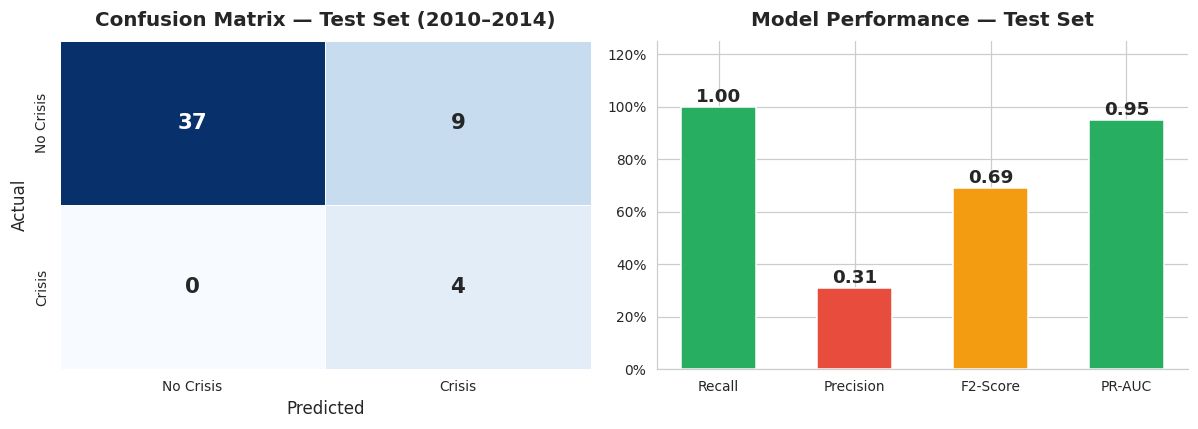

Test  Recall=100%  Precision=31%  F2=0.69  PR-AUC=0.950


In [18]:
# Scorecard figure
proba_test  = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test = (proba_test >= thr_xgb).astype(int)
cm_test  = confusion_matrix(y_test, y_pred_test)
rec_t    = recall_score(y_test, y_pred_test, zero_division=0)
pre_t    = precision_score(y_test, y_pred_test, zero_division=0)
f2_t     = fbeta_score(y_test, y_pred_test, beta=2, zero_division=0)
auc_t    = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Crisis', 'Crisis'],
            yticklabels=['No Crisis', 'Crisis'],
            linewidths=0.5, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title('Confusion Matrix - Test Set (2010–2014)',
                  fontweight='bold', pad=10)
mt = {'Recall': rec_t, 'Precision': pre_t, 'F2-Score': f2_t, 'PR-AUC': auc_t}
bars = axes[1].bar(
    list(mt.keys()), list(mt.values()),
    color=[PALETTE['success'] if v >= 0.7 else
           PALETTE['warning'] if v >= 0.5 else
           PALETTE['accent'] for v in mt.values()],
    edgecolor='white', width=0.55)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                 f'{h:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1.25)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('Model Performance — Test Set', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../outputs/figures/fig11_scorecard.png', dpi=150)
plt.show()

print(f'Test  Recall={rec_t:.0%}  Precision={pre_t:.0%}'
      f'  F2={f2_t:.2f}  PR-AUC={auc_t:.3f}')

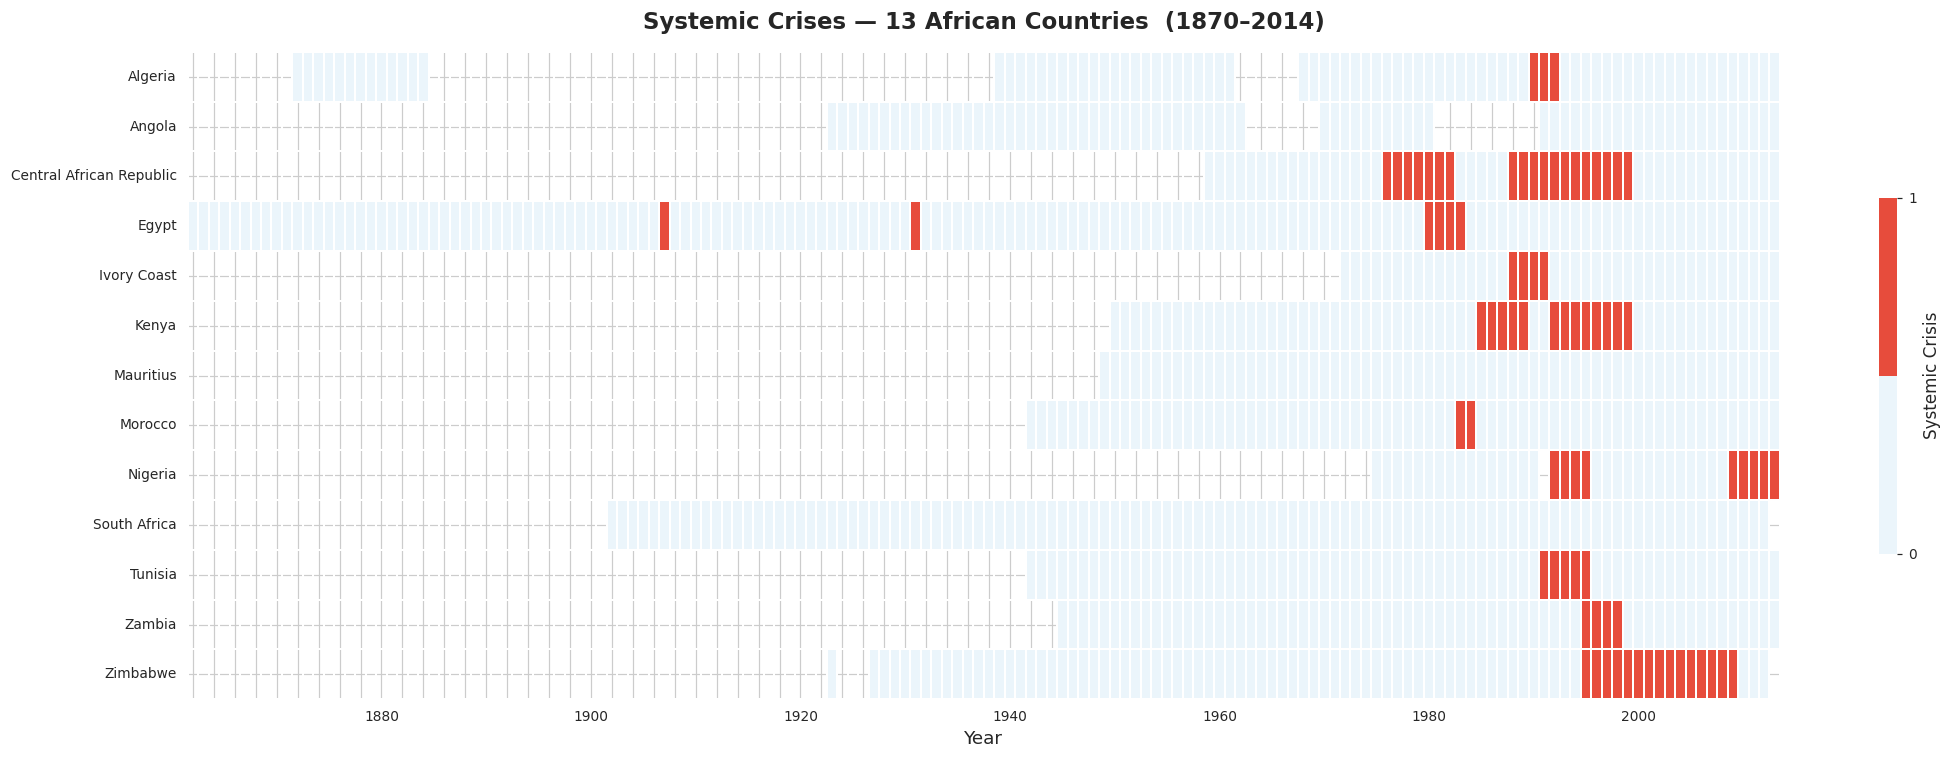

In [19]:
# EDA heatmap
crisis_pivot = df.pivot_table(
    index='country', columns='year',
    values='systemic_crisis', aggfunc='max')
fig, ax = plt.subplots(figsize=(20, 7))
sns.heatmap(crisis_pivot, cmap=['#EBF5FB', '#E74C3C'], ax=ax,
            cbar_kws={'label': 'Systemic Crisis', 'ticks': [0, 1], 'shrink': 0.55},
            linewidths=0.25, linecolor='white')
ax.set_title('Systemic Crises - 13 African Countries  (1870–2014)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
lbls = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticklabels(
    [y if int(y) % 20 == 0 else '' for y in lbls],
    rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/fig12_crisis_heatmap.png', dpi=150)
plt.show()

In [20]:
import os
import base64

def b64(path):
    if not os.path.exists(path): return ""
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode()

fig_paths = {
    'hm':  '../outputs/figures/fig12_crisis_heatmap.png',
    'bar': '../outputs/figures/fig1_shap_bar.png',
    'bee': '../outputs/figures/fig2_shap_beeswarm.png',
    'dep': '../outputs/figures/fig4_shap_dependence.png',
    'pr':  '../outputs/figures/fig9_pr_curves.png',
    'sc':  '../outputs/figures/fig11_scorecard.png',
    'wtp': '../outputs/figures/fig6_waterfall_tp.png',
    'wfp': '../outputs/figures/fig7_waterfall_fp.png',
    'cs':  '../outputs/figures/fig10_case_study.png',
}
imgs = {k: b64(v) for k, v in fig_paths.items()}

CSS = (
    '*{box-sizing:border-box;margin:0;padding:0}'
    'body{font-family:"Inter",system-ui,sans-serif;background:#F5F2ED;color:#2D2926;line-height:1.6}'

    # Header
    '.hdr{background:#FFFFFF;padding:50px 40px;border-bottom:1px solid #E2DED9;'
    'text-align:left;box-shadow:0 2px 15px rgba(0,0,0,0.02)}'
    '.hdr h1{font-size:2.4rem;font-weight:800;color:#2D2926;letter-spacing:-0.02em}'
    '.hdr h1 span{color:#AE592D;display:block;font-size:1.2rem;text-transform:uppercase;letter-spacing:2px;margin-top:5px}'
    '.hdr p{color:#6B6661;margin-top:15px;max-width:800px;font-size:1.05rem}'

    # Badge (мітки)
    '.meta{display:flex;gap:10px;margin-top:24px;flex-wrap:wrap}'
    '.badge{background:#FFFFFF;border-radius:6px;padding:6px 16px;font-size:0.85rem;'
    'border:1px solid #D1CDC7;color:#4A4641;font-weight:500}'

    '.main{padding:40px;max-width:1400px;margin:0 auto}'

    # KPI картки
    '.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:20px;margin-bottom:40px}'
    '.kpi{background:#FFFFFF;border-radius:16px;padding:24px 20px;text-align:center;'
    'box-shadow:0 4px 20px rgba(0,0,0,0.04);border:1px solid #E2DED9;transition:0.3s ease}'
    '.kpi:hover{transform:translateY(-5px)}'
    '.kv{font-size:2.2rem;font-weight:800;color:#AE592D;margin-bottom:4px}'
    '.kl{font-size:0.75rem;color:#8C8782;text-transform:uppercase;font-weight:600;letter-spacing:1px}'

    # Інтерпретація (Текстовий блок)
    '.interp{background:#FFFFFF;border-left:6px solid #AE592D;border-radius:12px;'
    'padding:30px;margin-bottom:40px;box-shadow:0 4px 20px rgba(0,0,0,0.04)}'
    '.interp h3{color:#AE592D;margin-bottom:12px;font-size:1.2rem;text-transform:uppercase}'
    '.interp p{font-size:1rem;color:#4A4641;opacity:0.9}'
    '.interp strong{color:#2D2926;font-weight:700}'

    # Сітки для графіків
    '.g1{margin-bottom:30px}'
    '.g2, .g3{display:grid;gap:30px;margin-bottom:30px}'
    '@media(min-width:900px){.g2{grid-template-columns:1fr 1fr}.g3{grid-template-columns:1fr 1fr 1fr}}'

    # Картки графіків
    '.card{background:#FFFFFF;border-radius:16px;overflow:hidden;border:1px solid #E2DED9;'
    'box-shadow:0 10px 30px rgba(0,0,0,0.03);transition:0.3s ease}'
    '.ch{padding:20px 24px;border-bottom:1px solid #F5F2ED;background:#FAF8F6}'
    '.ch h2{font-size:1rem;font-weight:700;color:#2D2926}'
    '.ch .sub{font-size:0.8rem;color:#8C8782;margin-top:4px}'
    '.cb{padding:20px;background:#FFFFFF}.cb img{width:100%;border-radius:8px;display:block}'

    'footer{text-align:center;padding:40px;font-size:0.85rem;color:#8C8782;border-top:1px solid #E2DED9;margin-top:20px}'
)

parts = []
parts.append('<!DOCTYPE html><html lang="en"><head>')
parts.append('<meta charset="UTF-8"><meta name="viewport" content="width=device-width,initial-scale=1.0">')
parts.append('<title>Africa Crisis Predict | Data Analysis</title>')

parts.append('<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;700;800&display=swap" rel="stylesheet">')
parts.append(f'<style>{CSS}</style></head><body>')

# Header
parts.append('<div class="hdr">')
parts.append('<h1>AFRICA CRISIS <span>Predictive Early Warning System</span></h1>')
parts.append('<p>Використання XGBoost для прогнозування системних економічних криз у 13 країнах Африки. Аналіз базується на історичних даних 1870–2014 років.</p>')
parts.append('<div class="meta">')
parts.append('<span class="badge">Model: XGBoost Classifier</span>')
parts.append('<span class="badge">Scope: 13 African Nations</span>')
parts.append('<span class="badge">Target: 1-Year Ahead Forecast</span>')
parts.append('</div></div>')

parts.append('<div class="main">')

# KPI Блок
parts.append('<div class="kpis">')
parts.append(f'<div class="kpi"><div class="kv">{rec_t:.0%}</div><div class="kl">Recall (Повнота)</div></div>')
parts.append(f'<div class="kpi"><div class="kv">{pre_t:.0%}</div><div class="kl">Precision (Точність)</div></div>')
parts.append(f'<div class="kpi"><div class="kv">{f2_t:.2f}</div><div class="kl">F2-Score</div></div>')
parts.append(f'<div class="kpi"><div class="kv">{auc_t:.3f}</div><div class="kl">PR-AUC</div></div>')
parts.append('</div>')

parts.append('<div class="interp"><h3>Ключові фактори впливу</h3>')
parts.append('<p>Найбільший вплив на прогноз має <strong>Банківська криза (lag 1)</strong>. Це підтверджує теорію про "подвійні кризи", де стрес у банківському секторі неминуче веде до системного колапсу. ')
parts.append('<strong>Інфляція (CPI)</strong> та валютні коливання виступають вторинними, але критичними сигналами дисбалансу економіки.</p></div>')

def card(title, sub, img_key):
    img = imgs.get(img_key, '')
    return (f'<div class="card"><div class="ch">'
            f'<h2>{title}</h2><div class="sub">{sub}</div></div>'
            f'<div class="cb"><img src="data:image/png;base64,{img}" alt="{title}"></div></div>')

parts.append(f'<div class="g1">{card("Історична мапа криз (1870–2014)", "Червоний колір позначає роки системних криз", "hm")}</div>')
parts.append('<div class="g2">')
parts.append(card("SHAP Global Importance", "Середній вплив ознак на модель", "bar"))
parts.append(card("SHAP Beeswarm", "Напрямок та сила впливу кожної змінної", "bee"))
parts.append('</div>')
parts.append(f'<div class="g1">{card("Аналіз залежностей (Top 3 Features)", "Вплив конкретних значень ознак на ймовірність кризи", "dep")}</div>')
parts.append('<div class="g3">')
parts.append(card("Аналіз True Positive", "Що призвело до вірного прогнозу", "wtp"))
parts.append(card("Аналіз False Positive", "Чому виникла хибна тривога", "wfp"))
parts.append(card("Scorecard результатів", "Підсумкова оцінка на тестовій вибірці", "sc"))
parts.append('</div>')

parts.append('</div>') # End main
parts.append('<footer>African Systemic Crisis Early Warning System · Проект на основі Machine Learning · 2026</footer>')
parts.append('</body></html>')


html = ''.join(parts)
with open('../outputs/early_warning_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html)
print(f'Dashboard saved: {len(html)//1024} KB')

Dashboard saved: 1043 KB
